# Choropleth Map & CHORD Chart - Data Analysis Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# Read json files from ../src/json/fips.json
# FIPS 10-4 to Country Name mapping
with open('../src/json/fips.json', 'r') as f:
    fips = json.load(f)

In [3]:
# Function to convert 2-letter FIPS 10-4 country codes to country names
def code_to_country(code):
    try:
        country = fips[code]
        return country
    except:
        raise ValueError(f"Invalid country code: {code}")

In [4]:
# Load  "../data/GDELT/gdelt_keys.parquet"  "../data/GDELT/gdelt_conflict_types.parquet" and "../data/GDELT/gdelt_volume_metrics.parquet" then join on "conflict_id"
# and display the first few rows of the resulting dataframe

gdelt_path = "../data/GDELT/"
df_keys = pd.read_parquet(gdelt_path + "gdelt_keys.parquet")
df_keys.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country
0,0,2026-01-12,UK,UNK,GBR,UP
1,1,2026-01-12,FR,FRA,USA,US
2,2,2026-01-12,IS,GBR,UNK,UK
3,3,2026-01-12,UP,EUR,RUS,UK
4,4,2026-01-12,EZ,SVK,UNK,EZ


In [5]:
df_volume = pd.read_parquet(gdelt_path + "gdelt_volume_metrics.parquet")
df_volume.head()

,conflict_id,mentions_count,distinct_events,distinct_media_sources
0,0,16,13,11
1,1,101,28,71
2,2,8,8,5
3,3,208,5,105
4,4,6,5,4


In [6]:
df_mention_types = pd.read_parquet(gdelt_path + "gdelt_conflict_types.parquet")
df_mention_types.head()

,conflict_id,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events
0,0,3,13,3,10
1,1,41,60,11,17
2,2,6,2,6,2
3,3,207,1,4,1
4,4,5,1,4,1


In [7]:
# Print length of each dataframe
print(f"Length of df_keys: {len(df_keys)}")
print(f"Length of df_volume: {len(df_volume)}")
print(f"Length of df_mention_types: {len(df_mention_types)}")

Length of df_keys: 7802681
Length of df_volume: 7802681
Length of df_mention_types: 7802681


In [10]:
# join just df_keys and df_mention_types on conflict_id
df_mentions = pd.merge(df_keys, df_mention_types, on='conflict_id')
df_mentions.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events
0,0,2026-01-12,UK,UNK,GBR,UP,3,13,3,10
1,1,2026-01-12,FR,FRA,USA,US,41,60,11,17
2,2,2026-01-12,IS,GBR,UNK,UK,6,2,6,2
3,3,2026-01-12,UP,EUR,RUS,UK,207,1,4,1
4,4,2026-01-12,EZ,SVK,UNK,EZ,5,1,4,1


In [11]:
print(f"Length of df_mentions: {len(df_mentions)}")

Length of df_mentions: 7802681


In [12]:
df_mentions.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events
0,0,2026-01-12,UK,UNK,GBR,UP,3,13,3,10
1,1,2026-01-12,FR,FRA,USA,US,41,60,11,17
2,2,2026-01-12,IS,GBR,UNK,UK,6,2,6,2
3,3,2026-01-12,UP,EUR,RUS,UK,207,1,4,1
4,4,2026-01-12,EZ,SVK,UNK,EZ,5,1,4,1


In [ ]:
print(len(df_mentions[df_mentions['media_country'] == 'UNK']))

20675


In [30]:
# Percent of 'UNK' in 'media_country' column weighted by 'material_conflict_mentions' with respect to the global sum
print((df_mentions[df_mentions['media_country'] == 'UNK']['material_conflict_mentions'].sum() / df_mentions['material_conflict_mentions'].sum())*100)

0.08083776884945448


In [31]:
# Dropping rows where 'media_country' is 'UNK'
df_mentions = df_mentions[df_mentions['media_country'] != 'UNK']
df_mentions.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events
0,0,2026-01-12,UK,UNK,GBR,UP,3,13,3,10
1,1,2026-01-12,FR,FRA,USA,US,41,60,11,17
2,2,2026-01-12,IS,GBR,UNK,UK,6,2,6,2
3,3,2026-01-12,UP,EUR,RUS,UK,207,1,4,1
4,4,2026-01-12,EZ,SVK,UNK,EZ,5,1,4,1


In [34]:
print((df_mentions[df_mentions['media_country'] == 'US']['material_conflict_mentions'].sum() / df_mentions['material_conflict_mentions'].sum())*100)

51.989626316498075


In [35]:
# Convert the 'conflict_country' column from FIPS 10-4 codes to country names
df_mentions['conflict_country_name'] = df_mentions['conflict_country'].apply(code_to_country)

In [36]:
# Convert the 'media_country' column from FIPS 10-4 codes to country names
df_mentions['media_country_name'] = df_mentions['media_country'].apply(code_to_country)

In [37]:
# Display the first few rows of the dataframe
df_mentions.head()

,conflict_id,mention_week,conflict_country,actor1_country,actor2_country,media_country,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events,conflict_country_name,media_country_name
0,0,2026-01-12,UK,UNK,GBR,UP,3,13,3,10,United Kingdom,Ukraine
1,1,2026-01-12,FR,FRA,USA,US,41,60,11,17,France,United States
2,2,2026-01-12,IS,GBR,UNK,UK,6,2,6,2,Israel,United Kingdom
3,3,2026-01-12,UP,EUR,RUS,UK,207,1,4,1,Ukraine,United Kingdom
4,4,2026-01-12,EZ,SVK,UNK,EZ,5,1,4,1,Czech Republic,Czech Republic


For doing the conversion in a way that all country codes are associated with their country names we used the official FIPS-10-4 list with some added codes that can be found in GDELT. The following few lines show all this.

In [38]:
# Reading ../src/json/fips_extension.json for extended FIPS codes
with open('../src/json/fips_extension.json', 'r') as f:
    fips_extension = json.load(f)

In [39]:
# Extracting the number of mentions for country codes in fips_extension
mentions_extension = {}
for code in fips_extension.keys():
    count = df_mentions[df_mentions['conflict_country'] == code].shape[0]
    mentions_extension[code] = count

# Print the mentions for the extension codes and the percentage of total mentions they represent
total_mentions = df_mentions.shape[0]

for code, count in mentions_extension.items():
    percentage = (count / total_mentions) * 100
    country_name = fips_extension[code]
    print(f"{country_name} ({code}): {count} mentions, {percentage:.2f}% of total")


Oceania (OC): 538 mentions, 0.01% of total
Oceans (OS): 8589 mentions, 0.11% of total
Serbia (RB): 21786 mentions, 0.28% of total
Serbia (YI): 776 mentions, 0.01% of total
Howland Island (HQ): 7 mentions, 0.00% of total
Kingman Reef (KQ): 2 mentions, 0.00% of total
Johnston Atoll (JQ): 1 mentions, 0.00% of total
Jarvis Island (DQ): 3 mentions, 0.00% of total
Palmyra Atoll (LQ): 1 mentions, 0.00% of total


The countries which have been added are not that relevant with respect to mentions, but we'll keep for now.

We will then drop some columns which will not be used in the Choropleth map.

In this first dataset we will extract we keep the aggregated columns 'mentions_count' and 'distinct_events' which also contain verbal conflict events.

In the following section we will extract another dataset containing only material conflict events and their respective mentions

## Material Conflict Only

In [41]:
columns_to_keep = ['mention_week', 'conflict_country_name', 'media_country_name', 'material_conflict_mentions', 'material_conflict_unique_events']
df_mentions_filtered_material = df_mentions[columns_to_keep]
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,media_country_name,material_conflict_mentions,material_conflict_unique_events
0,2026-01-12,United Kingdom,Ukraine,13,10
1,2026-01-12,France,United States,60,17
2,2026-01-12,Israel,United Kingdom,2,2
3,2026-01-12,Ukraine,United Kingdom,1,1
4,2026-01-12,Czech Republic,Czech Republic,1,1


In [43]:
n = 5
df_aggregated = df_mentions_filtered_material.groupby(
    ['media_country_name', 'mention_week', 'conflict_country_name']
).agg({
    'material_conflict_mentions': 'sum',
    'material_conflict_unique_events': 'sum'
}).reset_index()

df_aggregated = df_aggregated.sort_values('material_conflict_mentions', ascending=False)
df_top_mentions_material = df_aggregated.groupby(
    ['media_country_name', 'mention_week']
).head(n)

df_top_mentions_material = df_top_mentions_material.sort_values(
    by=['mention_week', 'media_country_name', 'material_conflict_mentions'], 
    ascending=[True, True, False]
)

df_top_mentions_material.head()

,media_country_name,mention_week,conflict_country_name,material_conflict_mentions,material_conflict_unique_events
0,Afghanistan,2015-02-16,Afghanistan,153,143
8,Afghanistan,2015-02-16,Pakistan,46,34
15,Afghanistan,2015-02-16,United States,19,12
9,Afghanistan,2015-02-16,Russia,19,12
2,Afghanistan,2015-02-16,Azerbaijan,18,9


In [44]:
# List of media_country:
media_countries = df_top_mentions_material['media_country_name'].unique()
conflict_countries = df_top_mentions_material['conflict_country_name'].unique()

In [45]:
print(media_countries)

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Chad' 'Chile' 'China' 'Colombia' 'Comoros' 'Costa Rica' 'Croatia' 'Cuba'
 'Cyprus' 'Czech Republic' 'Democratic Republic of Congo' 'Denmark'
 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Fiji' 'Finland' 'France'
 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Greenland' 'Guam'
 'Guatemala' 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland'
 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy'
 'Ivory Coast' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kosovo'
 'Kuwait' 'Kyrgyzstan' 'Latvia' 'Lebanon' 'Lesotho' 'Liberia' 'Libya'
 'Lithuania' 'Luxembourg' 'Madagascar' 'Malawi' 'Malaysia' 'Maldives'
 'Mali' 'Malta' 'Mauritania' 'Maur

In [46]:
print(conflict_countries)

['Afghanistan' 'Pakistan' 'United States' 'Russia' 'Azerbaijan' 'Albania'
 'Tunisia' 'Italy' 'Serbia' 'Egypt' 'Libya' 'Algeria' 'Israel' 'Syria'
 'Angola' 'Nigeria' 'Greece' 'Ukraine' 'France' 'Argentina' 'Sweden'
 'Iran' 'Uruguay' 'Venezuela' 'Armenia' 'Turkey' 'Australia' 'Indonesia'
 'Iraq' 'Bahamas' 'Guyana' 'Yemen' 'Bahrain' 'Bangladesh' 'India'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Mexico' 'Bermuda' 'Bolivia'
 'Chile' 'Bosnia and Herzegovina' 'Croatia' 'Botswana' 'Brazil' 'Myanmar'
 'Brunei' 'China' 'Bulgaria' 'Burkina Faso' 'Benin'
 'Democratic Republic of Congo' 'Ghana' 'Burundi' 'Cambodia' 'Cameroon'
 'Spain' 'Canada' 'Cayman Islands' 'Chad' 'Peru' 'Colombia' 'Comoros'
 'Costa Rica' 'Nicaragua' 'Cuba' 'Cyprus' 'Czech Republic'
 'Republic of Congo' 'Denmark' 'Germany' 'Ecuador' 'El Salvador'
 'Mauritius' 'Estonia' 'United Kingdom' 'Fiji' 'Finland' 'Gambia'
 'Georgia' 'Somalia' 'Greenland' 'Guam' 'Jordan' 'Micronesia' 'Guatemala'
 'Guinea' 'Haiti' 'Honduras' 'Palestine' 'Hun

Inspecting at a glance this behavior by building some small multiples scatterplots with the top-1 mention for each week and each media_country

In [47]:
# for all media countries (expect for 'LatAm (Left-Wing Block)' and 'Other' and 'Pan-Africa'), for all weeks, get the conflict_country_name with highest material_conflict_mentions. 
# If it is different than the media_country, we will save this fact for further use.

media_countries_filtered = ['Italy', 'United Arab Emirates', 'United Kingdom', 'United States', 'France', 'Germany', 'Greece', 'Australia', 'China', 'India']

media_coverage = {}

for media_country in media_countries_filtered:
    if media_country in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']:
        continue
    media_coverage[media_country] = {}
    df_media = df_top_mentions_material[df_top_mentions_material['media_country_name'] == media_country]
    for week in df_media['mention_week'].unique():
        media_coverage[media_country][week] = {}
        df_week = df_media[df_media['mention_week'] == week]
        top_conflict = df_week.iloc[0]
        if top_conflict['conflict_country_name'] != media_country:
            media_coverage[media_country][week]['country_name'] = top_conflict['conflict_country_name']
            media_coverage[media_country][week]['mentions'] = top_conflict['material_conflict_mentions']

In [48]:
# Here we are interested instead to see the top-1 mention, disregarding the fact that a country mention itself

media_coverage_total = {}

for media_country in media_countries_filtered:
    media_coverage_total[media_country] = {}
    df_media = df_top_mentions_material[df_top_mentions_material['media_country_name'] == media_country]
    for week in df_media['mention_week'].unique():
        media_coverage_total[media_country][week] = {}
        df_week = df_media[df_media['mention_week'] == week]
        top_conflict = df_week.iloc[0]
        media_coverage_total[media_country][week]['country_name'] = top_conflict['conflict_country_name']
        media_coverage_total[media_country][week]['mentions'] = top_conflict['material_conflict_mentions']

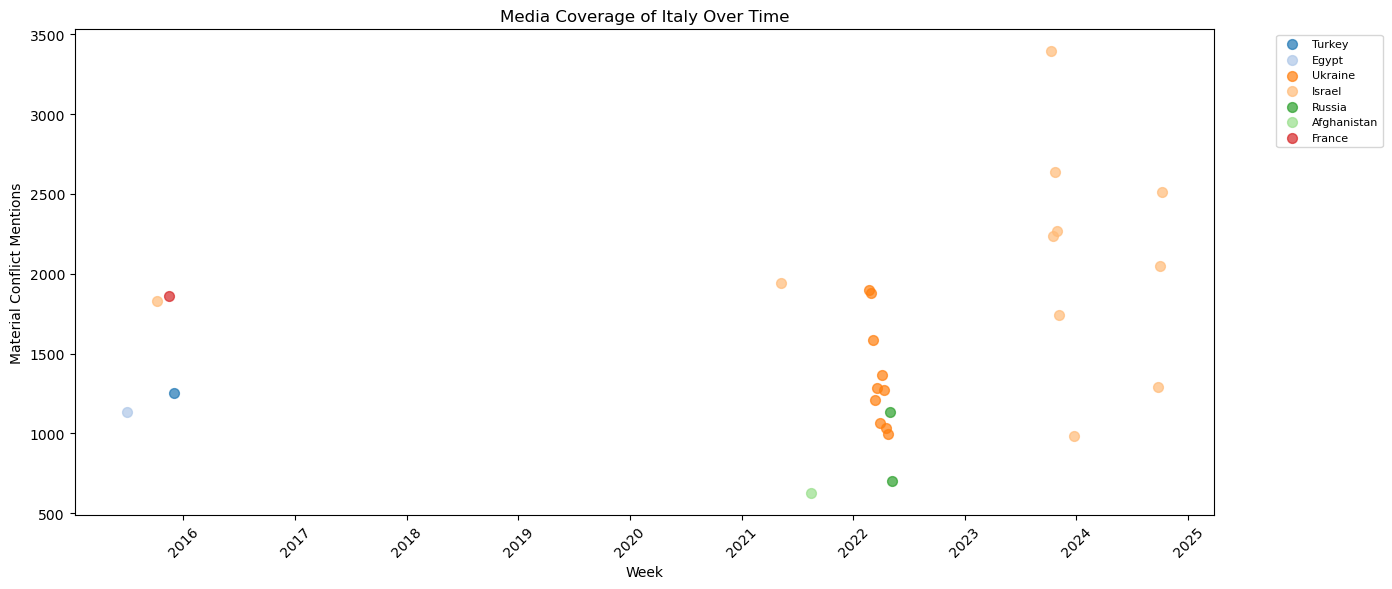

In [49]:
# Plot just for Italy
weeks = []
mentions = []
country_names = []
for week, data in media_coverage['Italy'].items():
    if data != {}:  # Only include non-empty data
        weeks.append(week)
        mentions.append(data['mentions'])
        country_names.append(data['country_name'])

# Convert weeks to datetime for better plotting
weeks_dt = pd.to_datetime(weeks)

plt.figure(figsize=(14, 6))
unique_countries = list(set(country_names))
colors = plt.cm.tab20(range(len(unique_countries)))
color_map = {country: colors[i] for i, country in enumerate(unique_countries)}

for country in unique_countries:
    indices = [i for i, c in enumerate(country_names) if c == country]
    plt.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                label=country, s=50, alpha=0.7, color=color_map[country])

plt.xlabel('Week')
plt.ylabel('Material Conflict Mentions')
plt.title('Media Coverage of Italy Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


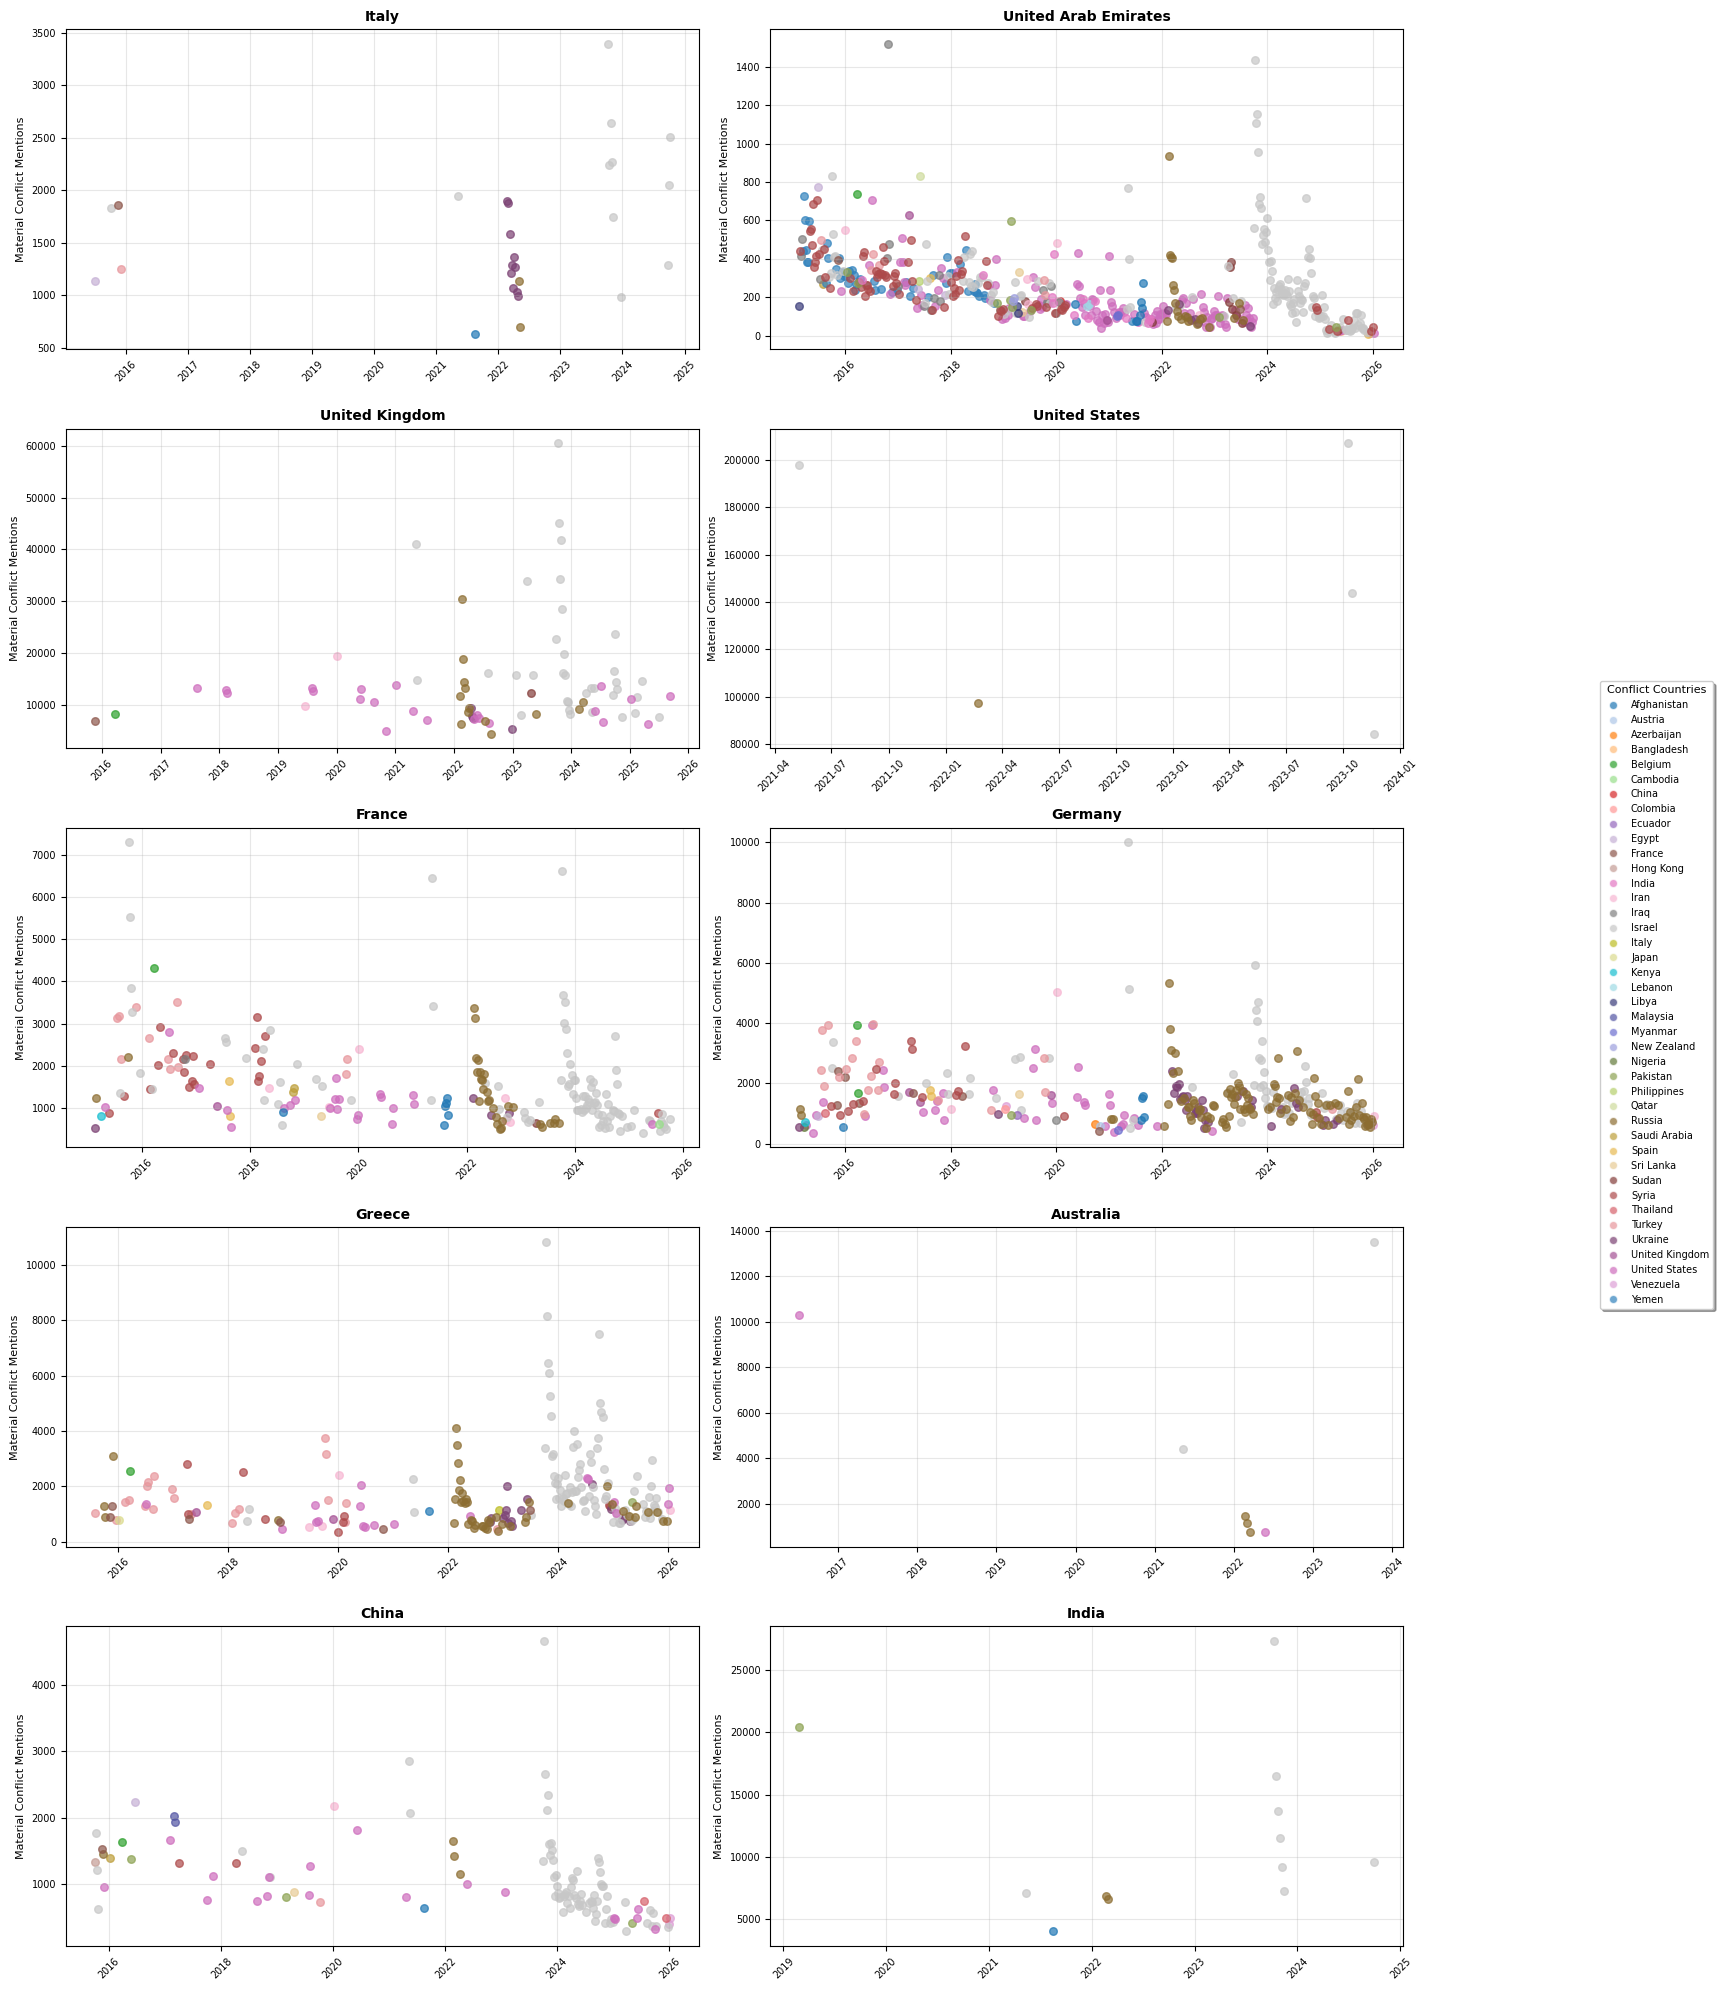

In [50]:
# Count actual countries to plot (excluding the 3 skipped ones)
countries_to_plot = [mc for mc in media_countries_filtered 
                     if mc not in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']]

# First pass: check which countries actually have data
countries_with_data = []
all_countries = set()

for media_country in countries_to_plot:
    country_key = media_country
    
    has_data = False
    for week, data in media_coverage[country_key].items():
        if data != {}:
            has_data = True
            all_countries.add(data['country_name'])
    
    #if has_data:
    countries_with_data.append(media_country)

n_countries = len(countries_with_data)

# Calculate grid size needed
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division

# Create the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Create diverse color map with enough colors
all_countries = sorted(list(all_countries))
n_colors = len(all_countries)

# Use multiple color maps to get distinct colors
if n_colors <= 20:
    colors = plt.cm.tab20(range(n_colors))
else:
    # Combine multiple colormaps for more distinct colors
    colors1 = plt.cm.tab20(range(20))
    colors2 = plt.cm.tab20b(range(min(20, n_colors - 20)))
    colors3 = plt.cm.tab20c(range(max(0, n_colors - 40)))
    colors = list(colors1) + list(colors2) + list(colors3)
    colors = colors[:n_colors]

color_map = {country: colors[i] for i, country in enumerate(all_countries)}

# Plot each media country that has data
idx = 0
for media_country in countries_with_data:
    country_key = media_country
    
    weeks = []
    mentions = []
    country_names = []
    for week, data in media_coverage[country_key].items():
        if data != {}:
            weeks.append(week)
            mentions.append(data['mentions'])
            country_names.append(data['country_name'])
    
    weeks_dt = pd.to_datetime(weeks)
    ax = axes[idx]
    
    unique_countries = list(set(country_names))
    
    for country in unique_countries:
        indices = [i for i, c in enumerate(country_names) if c == country]
        ax.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                   s=30, alpha=0.7, color=color_map[country])
    
    ax.set_title(f'{country_key}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('Material Conflict Mentions', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    idx += 1

# Hide unused subplots (if any)
for i in range(idx, len(axes)):
    axes[i].set_visible(False)

# Create shared legend with smaller font if many countries
legend_fontsize = 7 if n_colors > 30 else 8
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color_map[country], 
                      markersize=6, alpha=0.7, label=country) 
           for country in all_countries]

fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=legend_fontsize, title='Conflict Countries', 
           title_fontsize=legend_fontsize+1, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make space for legend
plt.show()

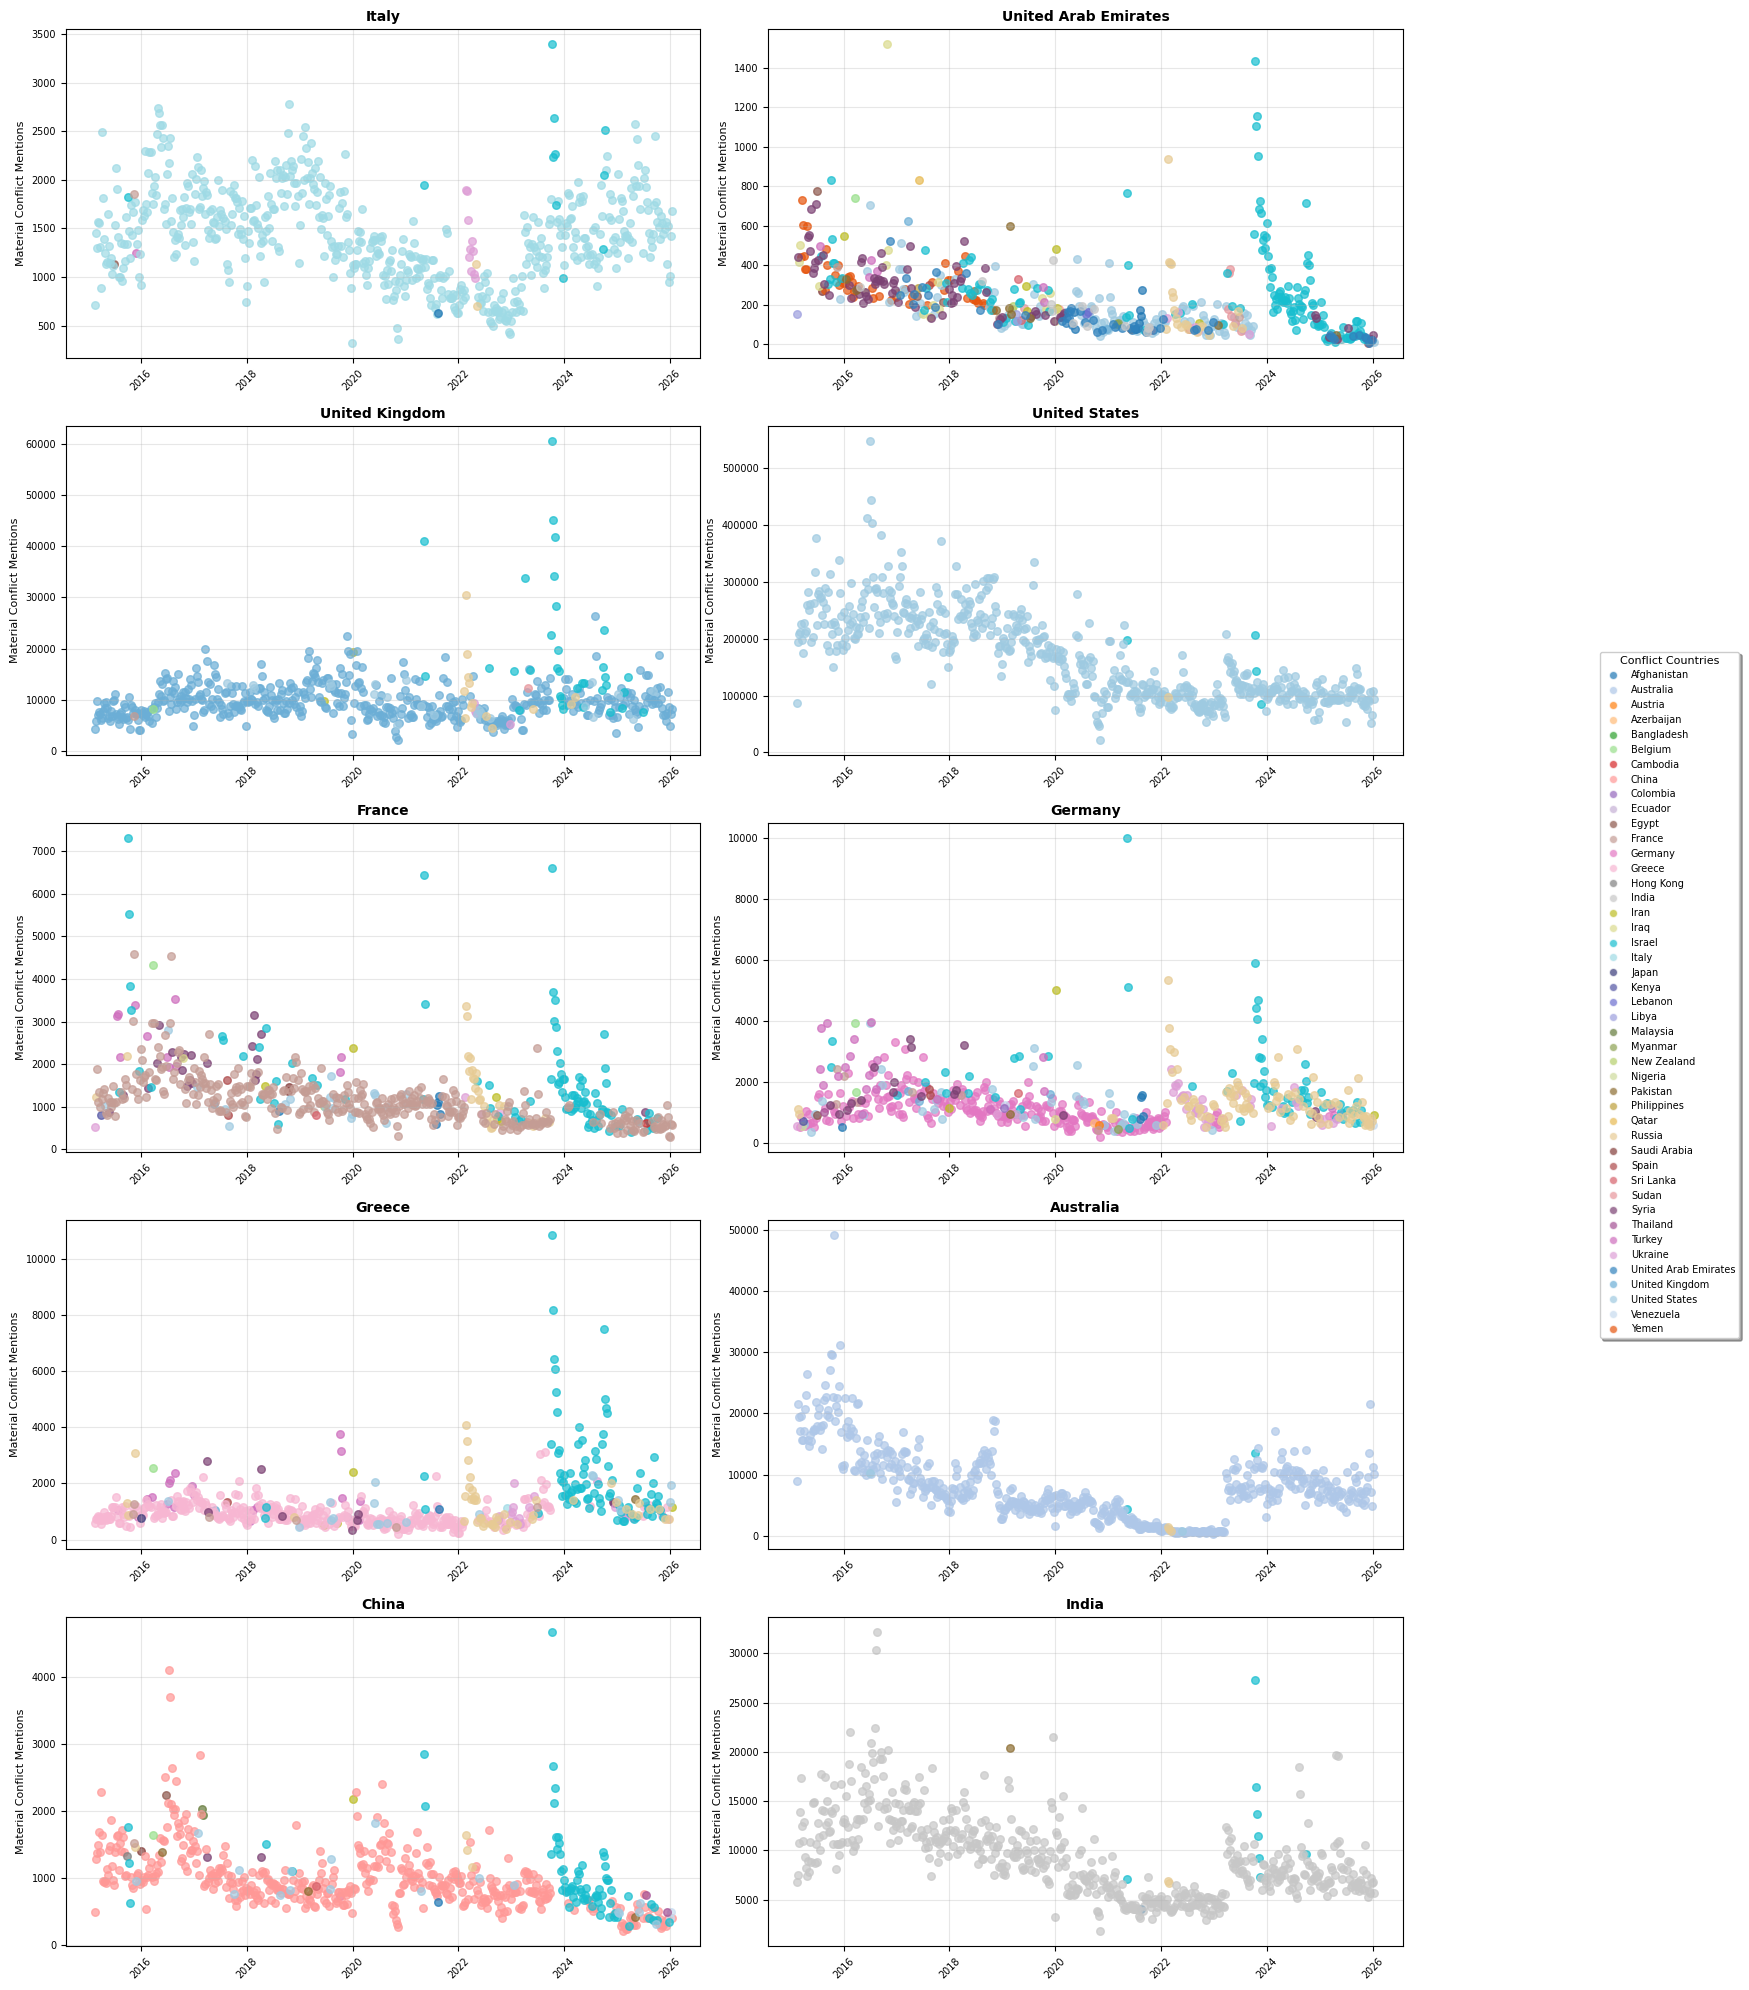

In [51]:
# Count actual countries to plot (excluding the 3 skipped ones)
countries_to_plot = [mc for mc in media_countries_filtered 
                     if mc not in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']]

# First pass: check which countries actually have data
countries_with_data = []
all_countries = set()

for media_country in countries_to_plot:
    country_key = media_country
    
    has_data = False
    for week, data in media_coverage_total[country_key].items():
        if data != {}:
            has_data = True
            all_countries.add(data['country_name'])
    
    #if has_data:
    countries_with_data.append(media_country)

n_countries = len(countries_with_data)

# Calculate grid size needed
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division

# Create the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Create diverse color map with enough colors
all_countries = sorted(list(all_countries))
n_colors = len(all_countries)

# Use multiple color maps to get distinct colors
if n_colors <= 20:
    colors = plt.cm.tab20(range(n_colors))
else:
    # Combine multiple colormaps for more distinct colors
    colors1 = plt.cm.tab20(range(20))
    colors2 = plt.cm.tab20b(range(min(20, n_colors - 20)))
    colors3 = plt.cm.tab20c(range(max(0, n_colors - 40)))
    colors = list(colors1) + list(colors2) + list(colors3)
    colors = colors[:n_colors]

color_map = {country: colors[i] for i, country in enumerate(all_countries)}

# Plot each media country that has data
idx = 0
for media_country in countries_with_data:
    country_key = media_country
    
    weeks = []
    mentions = []
    country_names = []
    for week, data in media_coverage_total[country_key].items():
        if data != {}:
            weeks.append(week)
            mentions.append(data['mentions'])
            country_names.append(data['country_name'])
    
    weeks_dt = pd.to_datetime(weeks)
    ax = axes[idx]
    
    unique_countries = list(set(country_names))
    
    for country in unique_countries:
        indices = [i for i, c in enumerate(country_names) if c == country]
        ax.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                   s=30, alpha=0.7, color=color_map[country])
    
    ax.set_title(f'{country_key}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('Material Conflict Mentions', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    idx += 1

# Hide unused subplots (if any)
for i in range(idx, len(axes)):
    axes[i].set_visible(False)

# Create shared legend with smaller font if many countries
legend_fontsize = 7 if n_colors > 30 else 8
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color_map[country], 
                      markersize=6, alpha=0.7, label=country) 
           for country in all_countries]

fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=legend_fontsize, title='Conflict Countries', 
           title_fontsize=legend_fontsize+1, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make space for legend
plt.show()

In [53]:
# Load the json file for the map: ../src/json/world.json
geo_path = "../src/json/world.json"
with open(geo_path, 'r') as f:
    world_json = json.load(f)

geo_countries = set([feature['properties']['name'] for feature in world_json['features']])
# Countries in df_top_mentions_material not in geo_countries
missing_countries_material = set(df_top_mentions_material['media_country_name'].unique()) - geo_countries
print("Countries in df_top_mentions_material not in geo_countries:", missing_countries_material)

Countries in df_top_mentions_material not in geo_countries: {'Macau', 'Dominica', 'Samoa', 'Seychelles', 'Guam', 'Grenada', 'Cook Islands', 'Virgin Islands, U.S.', 'Maldives', 'Bermuda', 'Monaco', 'Montserrat', 'Hong Kong', 'Saint Lucia', 'Comoros', 'Micronesia', 'Barbados', 'Turks and Caicos Islands', 'Andorra', 'Mayotte', 'Bahrain', 'Cape Verde', 'Kiribati', 'Antigua and Barbuda', 'Mauritius', 'Saint Kitts and Nevis', 'Gibraltar', 'British Indian Ocean Territory', 'Singapore', 'Faroe Islands', 'Cayman Islands', 'Tonga', 'British Virgin Islands', 'Martinique', 'Anguilla', 'Reunion', 'Malta', 'Sao Tome and Principe', 'Saint Vincent and the Grenadines'}


In [54]:
print('United Kingdom' in geo_countries)
print('United Arab Emirates' in geo_countries)
print('United States' in geo_countries)

True
True
True


### Datasets Creation

We will focus only on material conflict events from now on.

We are finally ready to create the datasets for the choropleth map and chord chart.

For the choropleth map we need the top 1 mention for each country and week and also some metadata like a label.

For the chord chart we need the top 5 mentions for each country and week and the same metadata.

First we finish cleaning the dataframe a bit more by dropping some unneeded columns and rows.

In [57]:
# Find the percentage of countries in df_mentions_filtered_material for each 'media_country' (with respect to material_conflict_mentions)
total_mentions_material = df_mentions_filtered_material['material_conflict_mentions'].sum()
percentage_mentions_material = df_mentions_filtered_material.groupby('media_country_name')['material_conflict_mentions'].sum() / total_mentions_material * 100

# Sort descending and print
percentage_mentions_material = percentage_mentions_material.sort_values(ascending=False)
print(percentage_mentions_material)

media_country_name
United States                     51.989626
United Kingdom                     5.182212
India                              3.971140
Israel                             3.850343
Canada                             2.976661
                                    ...    
East Timor                         0.000004
Kiribati                           0.000002
British Indian Ocean Territory     0.000002
Equatorial Guinea                  0.000002
Monaco                             0.000002
Name: material_conflict_mentions, Length: 208, dtype: float64


A collection bias toward English-speaking countries and United States especially is evident in the data. This is something to keep in mind when analyzing the results.

Reasons for US Dominance in GDELT:

1. English-language bias: GDELT heavily indexes English-language news sources, and the US has the largest English-language media ecosystem globally.
2. Internet infrastructure: US-based news websites, domains, and servers are vastly overrepresented in automated web crawling.
3. News agency distribution: Major US news agencies (AP, Reuters US operations, Bloomberg, etc.) produce content that gets republished globally, but the original source is often US-based.
4. GDELT's source collection: The project started with a US academic focus and has inherent biases toward Western, particularly American, sources.


In [59]:
# Set difference between media_country and conflict_country_name
set(df_mentions_filtered_material['media_country_name'].unique()) - set(df_mentions_filtered_material['conflict_country_name'].unique())

set()

In [60]:
# Load the label mapping json file
with open('../src/json/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

In [61]:
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,media_country_name,material_conflict_mentions,material_conflict_unique_events
0,2026-01-12,United Kingdom,Ukraine,13,10
1,2026-01-12,France,United States,60,17
2,2026-01-12,Israel,United Kingdom,2,2
3,2026-01-12,Ukraine,United Kingdom,1,1
4,2026-01-12,Czech Republic,Czech Republic,1,1


In [63]:
# Adding two new columns: 'conflict_continent' and 'media_continent' based on the label_mapping
def country_to_continent(country):
    try:
        for continent, countries in label_mapping.items():
            if country in countries:
                return continent
    #return 'Other'  # For countries not found in the mapping
    except:
        raise ValueError(f"Invalid country name: {country}")

In [64]:
df_mentions_filtered_material['conflict_continent'] = df_mentions_filtered_material['conflict_country_name'].apply(country_to_continent)

C:\Users\HEW14SDQ1006NL\AppData\Local\Temp\ipykernel_30124\1389982297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mentions_filtered_material['conflict_continent'] = df_mentions_filtered_material['conflict_country_name'].apply(country_to_continent)


In [66]:
# Renaming 'media_country_name' to 'media_country' for consistency
df_mentions_filtered_material['media_country'] = df_mentions_filtered_material['media_country_name']
df_mentions_filtered_material.head()

C:\Users\HEW14SDQ1006NL\AppData\Local\Temp\ipykernel_30124\746867472.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mentions_filtered_material['media_country'] = df_mentions_filtered_material['media_country_name']


,mention_week,conflict_country_name,media_country_name,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_country
0,2026-01-12,United Kingdom,Ukraine,13,10,Europe,Ukraine
1,2026-01-12,France,United States,60,17,Europe,United States
2,2026-01-12,Israel,United Kingdom,2,2,Asia,United Kingdom
3,2026-01-12,Ukraine,United Kingdom,1,1,Europe,United Kingdom
4,2026-01-12,Czech Republic,Czech Republic,1,1,Europe,Czech Republic


In [67]:
# Dropping 'media_country_name' column as it's now redundant
df_mentions_filtered_material = df_mentions_filtered_material.drop(columns=['media_country_name'])

In [68]:
df_mentions_filtered_material['media_continent'] = df_mentions_filtered_material['media_country'].apply(country_to_continent)

In [72]:
df_aggregated = df_mentions_filtered_material.groupby(
    ['media_country', 'media_continent', 'mention_week', 'conflict_country_name', 'conflict_continent']
).agg({
    'material_conflict_mentions': 'sum',
    'material_conflict_unique_events': 'sum'
}).reset_index()

df_aggregated = df_aggregated.sort_values('material_conflict_mentions', ascending=False)

In [73]:
# Choropleth map dataset:
df_top_1_mentions_material = df_aggregated.groupby(
    ['media_country', 'media_continent', 'mention_week']
).head(1)

df_top_1_mentions_material = df_top_1_mentions_material.sort_values(
    by=['mention_week', 'media_country', 'media_continent', 'material_conflict_mentions'],
    ascending=[True, True, True, False]
)

df_top_1_mentions_material.head()

,media_country,media_continent,mention_week,conflict_country_name,conflict_continent,material_conflict_mentions,material_conflict_unique_events
0,Afghanistan,Asia,2015-02-16,Afghanistan,Asia,153,143
8896,Albania,Europe,2015-02-16,Albania,Europe,73,62
18279,Algeria,Africa,2015-02-16,Egypt,Africa,119,59
24608,Angola,Africa,2015-02-16,Angola,Africa,17,14
27371,Argentina,South America,2015-02-16,Argentina,South America,824,268


In [74]:
# Save as csv df_top_mentions_material 
output_path = "../data/processed/choropleth_top_1_material_conflict.csv"
df_top_1_mentions_material.to_csv(output_path, index=False)

For the weekly top 5 conflict countries

In [75]:
df_aggregated = df_mentions_filtered_material.groupby(
    ['mention_week', 'conflict_country_name', 'conflict_continent']
).agg({
    'material_conflict_mentions': 'sum',
    'material_conflict_unique_events': 'sum'
}).reset_index()

df_aggregated = df_aggregated.sort_values('material_conflict_mentions', ascending=False)

In [78]:
# Weekly top dataset:
n = 5
df_top_n_mentions_material = df_aggregated.groupby(
    ['mention_week']
).head(n)

df_top_n_mentions_material = df_top_n_mentions_material.sort_values(
    by=['mention_week', 'material_conflict_mentions'],
    ascending=[True, False]
)

df_top_n_mentions_material.tail(10)

,mention_week,conflict_country_name,conflict_continent,material_conflict_mentions,material_conflict_unique_events
113442,2026-01-05,United States,North America,136947,52653
113445,2026-01-05,Venezuela,South America,40249,17760
113341,2026-01-05,Iran,Asia,17571,6876
113405,2026-01-05,Russia,Europe,15155,8485
113439,2026-01-05,Ukraine,Europe,15144,7728
113629,2026-01-12,United States,North America,113405,46503
113528,2026-01-12,Iran,Asia,29633,13666
113628,2026-01-12,United Kingdom,Europe,14819,5353
113531,2026-01-12,Israel,Asia,14695,8099
113634,2026-01-12,Venezuela,South America,13742,5518


In [81]:
# Save as csv df_top_n_mentions_material
output_path = "../data/processed/weekly_top_5_material_conflict.csv"
df_top_n_mentions_material.to_csv(output_path, index=False)

For the chord chart we need the top 5 mentions for each continent and week.

In [82]:
# First, create the basic continent-to-continent aggregation
chord_data = df_mentions_filtered_material.groupby(
    ['mention_week', 'media_continent', 'conflict_continent']
).agg({
    'material_conflict_mentions': 'sum',
    'material_conflict_unique_events': 'sum'
}).reset_index()

In [83]:
chord_data.head(10)

,mention_week,media_continent,conflict_continent,material_conflict_mentions,material_conflict_unique_events
0,2015-02-16,Africa,Africa,16845,9031
1,2015-02-16,Africa,Asia,4631,2035
2,2015-02-16,Africa,Europe,2319,996
3,2015-02-16,Africa,North America,1106,500
4,2015-02-16,Africa,Oceania,74,35
5,2015-02-16,Africa,South America,67,37
6,2015-02-16,Asia,Africa,8669,5402
7,2015-02-16,Asia,Asia,41633,25732
8,2015-02-16,Asia,Europe,6212,3898
9,2015-02-16,Asia,North America,3471,2239


In [92]:
# Now, for each week + media_continent + conflict_continent combination,
# get the top 5 conflict countries
n = 5
top_countries_detail = df_mentions_filtered_material.groupby(
    ['mention_week', 'media_continent', 'conflict_continent', 'conflict_country_name']
).agg({
    'material_conflict_mentions': 'sum',
    'material_conflict_unique_events': 'sum'
}).reset_index()

# Get top 5 countries for each combination
top_countries_detail = (
    top_countries_detail
    .sort_values('material_conflict_mentions', ascending=False)
    .groupby(['mention_week', 'media_continent', 'conflict_continent'])
    .head(n)  # Change to 3 if you want top 3
)

In [93]:
# Create a summary string for each group
def create_top_countries_string(group, n=5):
    countries = group.nlargest(n, 'material_conflict_mentions')
    details = []
    # json style key-value pairs
    for _, row in countries.iterrows():
        details.append(f"\"{row['conflict_country_name']}\": \"{int(row['material_conflict_mentions'])}\"")
    details = ",".join(details)
    return '{' + details + '}'

In [94]:
top_countries_summary = (
    top_countries_detail
    .groupby(['mention_week', 'media_continent', 'conflict_continent'])
    .apply(create_top_countries_string, n=n)
    .reset_index()
    .rename(columns={0: 'top_countries_detail'})
)

# Merge with the main chord data
chord_data_with_detail = chord_data.merge(
    top_countries_summary,
    on=['mention_week', 'media_continent', 'conflict_continent'],
    how='left'
)

C:\Users\HEW14SDQ1006NL\AppData\Local\Temp\ipykernel_30124\3966467036.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(create_top_countries_string, n=n)


In [95]:
print("Chord data sample:")
chord_data_with_detail.head()

Chord data sample:


,mention_week,media_continent,conflict_continent,material_conflict_mentions,material_conflict_unique_events,top_countries_detail
0,2015-02-16,Africa,Africa,16845,9031,"{""Nigeria"": ""4127"",""Egypt"": ""3167"",""Libya"": ""1..."
1,2015-02-16,Africa,Asia,4631,2035,"{""Syria"": ""1558"",""Iraq"": ""596"",""Turkey"": ""463""..."
2,2015-02-16,Africa,Europe,2319,996,"{""Ukraine"": ""976"",""United Kingdom"": ""411"",""Fra..."
3,2015-02-16,Africa,North America,1106,500,"{""United States"": ""1100"",""Mexico"": ""6"",""Canada..."
4,2015-02-16,Africa,Oceania,74,35,"{""Australia"": ""74""}"


In [96]:
# Save to CSV
chord_data_with_detail.to_csv("../data/processed/chord_continent_data.csv", index=False)

Now a sankey diagram can be built using this data.

In [97]:
# Step 1: For each week and media_continent, find top 10 conflict_countries
top_conflicts_per_continent = (
    df_mentions_filtered_material
    .groupby(['mention_week', 'media_continent', 'conflict_country_name'])
    .agg({
        'material_conflict_mentions': 'sum',
        'material_conflict_unique_events': 'sum',
        'conflict_continent': 'first'  # Keep the conflict continent
    })
    .reset_index()
    .sort_values(['mention_week', 'media_continent', 'material_conflict_mentions'], ascending=[True, True, False])
    .groupby(['mention_week', 'media_continent'])
    .head(10)  # Top 10 conflict countries
)
top_conflicts_per_continent.head()

,mention_week,media_continent,conflict_country_name,material_conflict_mentions,material_conflict_unique_events,conflict_continent
64,2015-02-16,Africa,Nigeria,4127,2704,Africa
22,2015-02-16,Africa,Egypt,3167,1654,Africa
50,2015-02-16,Africa,Libya,1912,1002,Africa
86,2015-02-16,Africa,Syria,1558,601,Asia
59,2015-02-16,Africa,Morocco,1337,179,Africa


In [98]:
# Step 2: Now get the breakdown by media_country for these top conflicts
# First, create a list of (week, media_continent, conflict_country) combinations
top_conflicts_list = top_conflicts_per_continent[
    ['mention_week', 'media_continent', 'conflict_country_name']
].drop_duplicates()

In [99]:
# Merge back with original data to get media_country breakdown
sankey_data = df_mentions_filtered_material.merge(
    top_conflicts_list,
    on=['mention_week', 'media_continent', 'conflict_country_name'],
    how='inner'
)
sankey_data.head()

,mention_week,conflict_country_name,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_country,media_continent
0,2026-01-12,United Kingdom,13,10,Europe,Ukraine,Europe
1,2026-01-12,Israel,2,2,Asia,United Kingdom,Europe
2,2026-01-12,Ukraine,1,1,Europe,United Kingdom,Europe
3,2026-01-12,Israel,7,6,Asia,Israel,Asia
4,2026-01-12,Israel,0,0,Asia,Australia,Oceania


In [100]:
# Keep only relevant columns
sankey_data = sankey_data[[
    'mention_week',
    'media_continent',
    'media_country',
    'conflict_country_name',
    'conflict_continent',
    'material_conflict_mentions',
    'material_conflict_unique_events'
]]


In [101]:
sankey_data.head(20)

,mention_week,media_continent,media_country,conflict_country_name,conflict_continent,material_conflict_mentions,material_conflict_unique_events
0,2026-01-12,Europe,Ukraine,United Kingdom,Europe,13,10
1,2026-01-12,Europe,United Kingdom,Israel,Asia,2,2
2,2026-01-12,Europe,United Kingdom,Ukraine,Europe,1,1
3,2026-01-12,Asia,Israel,Israel,Asia,7,6
4,2026-01-12,Oceania,Australia,Israel,Asia,0,0
5,2026-01-12,Europe,Ireland,Iran,Asia,28,25
6,2026-01-12,Europe,Ukraine,Russia,Europe,203,166
7,2026-01-12,Africa,Nigeria,Iran,Asia,5,5
8,2026-01-12,Europe,Ukraine,Venezuela,South America,16,11
9,2026-01-12,Asia,China,United States,North America,3,1


In [102]:
print(f"\nTotal rows: {len(sankey_data)}")



Total rows: 3424083


In [103]:
# Create separate files for each continent
for continent in df_mentions_filtered_material['media_continent'].unique():
    continent_sankey = sankey_data[sankey_data['media_continent'] == continent]
    
    # Save with continent name in filename
    filename = f"sankey_{continent.replace(' ', '_').lower()}.csv"
    continent_sankey.to_csv(f"../data/processed/{filename}", index=False)
    
    print(f"\n{continent} - {len(continent_sankey)} rows")


Europe - 1171964 rows

North America - 690534 rows

Asia - 977142 rows

Oceania - 138233 rows

South America - 194584 rows

Africa - 251626 rows


Now for a line chart I need to save as csv df_mentions_filtered_material

In [104]:
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,material_conflict_mentions,material_conflict_unique_events,conflict_continent,media_country,media_continent
0,2026-01-12,United Kingdom,13,10,Europe,Ukraine,Europe
1,2026-01-12,France,60,17,Europe,United States,North America
2,2026-01-12,Israel,2,2,Asia,United Kingdom,Europe
3,2026-01-12,Ukraine,1,1,Europe,United Kingdom,Europe
4,2026-01-12,Czech Republic,1,1,Europe,Czech Republic,Europe


In [ ]:
# Dropping the 'media_continent', 'media_country' columns
df_mentions_filtered_material = df_mentions_filtered_material.drop(columns=['media_continent', 'media_country'])

In [107]:
df_mentions_filtered_material.head(20)

,mention_week,conflict_country_name,material_conflict_mentions,material_conflict_unique_events,conflict_continent
0,2026-01-12,United Kingdom,13,10,Europe
1,2026-01-12,France,60,17,Europe
2,2026-01-12,Israel,2,2,Asia
3,2026-01-12,Ukraine,1,1,Europe
4,2026-01-12,Czech Republic,1,1,Europe
5,2026-01-12,Israel,7,6,Asia
6,2026-01-12,Israel,0,0,Asia
7,2026-01-12,Yemen,2,2,Asia
8,2026-01-12,Greenland,2,1,North America
9,2026-01-12,Iran,28,25,Asia


In [108]:
df_mentions_filtered_material = df_mentions_filtered_material.groupby(
    ['mention_week', 'conflict_continent', 'conflict_country_name']
).agg({
    'material_conflict_mentions': 'sum',
    'material_conflict_unique_events': 'sum'
}).reset_index()


In [109]:
df_mentions_filtered_material.head()

,mention_week,conflict_continent,conflict_country_name,material_conflict_mentions,material_conflict_unique_events
0,2015-02-16,Africa,Algeria,239,153
1,2015-02-16,Africa,Angola,23,19
2,2015-02-16,Africa,Benin,203,78
3,2015-02-16,Africa,Botswana,11,10
4,2015-02-16,Africa,Burkina Faso,281,25


In [110]:
# Save as csv df_mentions_filtered_material
output_path = "../data/processed/racing_line_chart.csv"
df_mentions_filtered_material.to_csv(output_path, index=False)